In [23]:
!uv pip install matplotlib

/Users/everett-founder/git/vangelis/internal/work/libs/archetype/.venv/lib/python3.10/site-packages/lancedb/__init__.py:220: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn instead.
  warnings.warn(


Using Python 3.10.16 environment at: /Users/everett-founder/git/vangelis/internal/work/libs/archetype/.venv
Resolved 11 packages in 1.81s                                        
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)----     0 B/2.61 MiB                      
fonttools  ------------------------------     0 B/2.61 MiB
⠙ Preparing packages... (0/2)----     0 B/7.67 MiB                      
fonttools  ------------------------------ 16.00 KiB/2.61 MiB
⠙ Preparing packages... (0/2)----     0 B/7.67 MiB                      
fonttools  ------------------------------ 16.00 KiB/2.61 MiB
⠙ Preparing packages... (0/2)---- 16.00 KiB/7.67 MiB                    
fonttools  ------------------------------ 29.08 KiB/2.61 MiB
⠙ Preparing packages... (0/2)---- 16.00 KiB/7.67 MiB                    
fonttools  ------------------------------ 29.08 KiB/2.61 MiB
⠙ Preparing packages... (0/2)---- 32.00 KiB/7.67 MiB                    


In [5]:
import sys
import os

# Ensure the parent directory is in sys.path so 'archetype' can be imported
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..", "src"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)


### Define Components and Processors 

In [30]:
from archetype import make_simple_world

world = make_simple_world("/Users/everett-founder/git/vangelis/internal/work/libs/archetype/data")
session = world.get_session()
df = session.get_table("archetype_Hel").to_dataframe()


In [39]:
# List recent simulations and runs 
runs = df.select("simulation", "run").distinct().limit(10).collect()
latest_simulation = runs["simulation"][0]
latest_run = runs["run"][0]

# Get the latest simulation and run
latest_simulation = runs.select(simulation).max()
latest_run = runs.select(run).max()


╭──────────────────────────┬────────────────────────────────╮
│ simulation               ┆ run                            │
│ ---                      ┆ ---                            │
│ Utf8                     ┆ Utf8                           │
╞══════════════════════════╪════════════════════════════════╡
│ sim_2025-05-25T22:33:25Z ┆ run_01JW4S8MS05TZX3DNENTY8N1A… │
├╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌┼╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌┤
│ sim_2025-05-25T22:32:13Z ┆ run_01JW4S6EGFHS8ASP3DHSTBYSD… │
├╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌┼╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌┤
│ sim_2025-05-25T22:33:41Z ┆ run_01JW4S94KD69QP9C780SYTRFC… │
├╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌┼╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌┤
│ sim_2025-05-25T22:54:50Z ┆ run_01JW4TFVQT0WYZQYWTVP2HZM5… │
╰──────────────────────────┴────────────────────────────────╯

(Showing first 4 of 4 rows)


In [31]:
filtered_df = df.select("entity_id","step", "position__x", "position__y").where(col("entity_id") == 1).where(limit(10)

In [32]:
import matplotlib.pyplot as plt

pd_df = filtered_df.to_pandas()


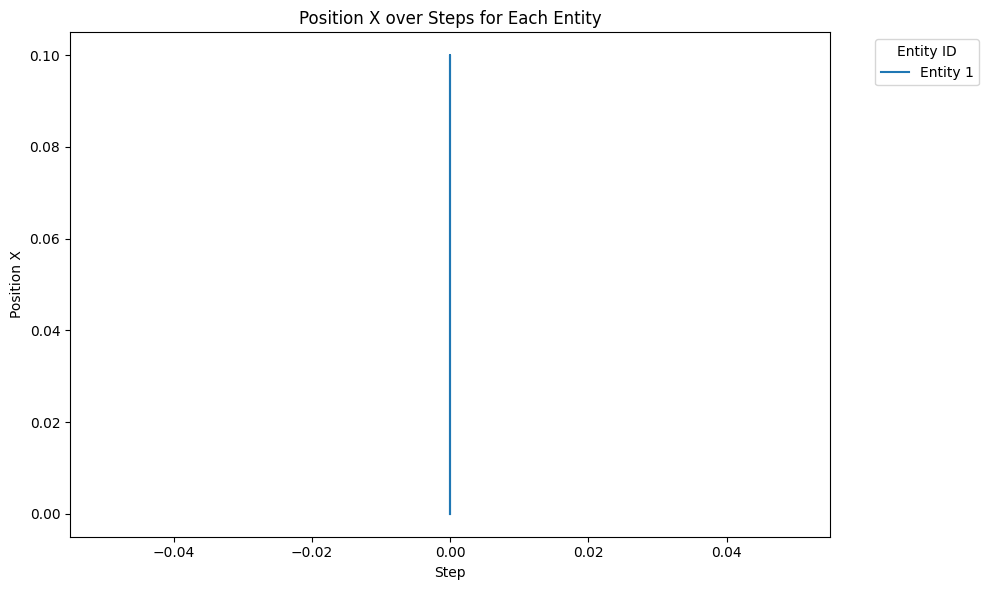

In [33]:
plt.figure(figsize=(10, 6))
for entity_id, group in pd_df.groupby("entity_id"):
    plt.plot(group["step"], group["position__x"], label=f"Entity {entity_id}")

plt.xlabel("Step")
plt.ylabel("Position X")
plt.title("Position X over Steps for Each Entity")
plt.legend(title="Entity ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
